### Stochastic interpolant demo: uniform angles → 1D classical XY chain

A minimal, self-contained illustration of the `eesi` interpolant framework on the
**periodic angle manifold** $(S^1)^N$, using the recently implemented XY-model
pieces (`xyEESI`, `XYChainGNN`, and the `eesi.datasets.xy` Monte-Carlo sampler).

We learn a generative map from a simple **base** to a physical **target**:

- **Base** $p_0$: independent uniform angles on the circle — trivial to sample.
- **Target** $p_1$: Boltzmann configurations of the 1D classical XY chain,
  $E(\theta) = J\sum_i \cos(\theta_{i+1}-\theta_i)$, drawn with the Metropolis
  sampler in `eesi.datasets.xy`.

`xyEESI` overrides the Euclidean interpolant with the minimum-image **geodesic**
on $(S^1)^N$, training a tangent-space drift $b(t,x)$ and score $s(t,x)$ along

$$x_t = \mathrm{wrap}\!\big(x_0 + \beta(t)\,d + \gamma(t)\,z\big),\quad d=\mathrm{wrap}(x_1-x_0),\ z\sim N(0,I),$$

so it pairs with the wrap-aware `XYChainGNN`, whose output is a per-spin tangent
scalar. This notebook runs the full pipeline — **data**, **model**, **training**,
**sampling**, and **entropy** — on a deliberately tiny **two-spin** chain, as an
end-to-end smoke test before scaling up.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import iv
from scipy.optimize import linear_sum_assignment

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import xyEESI, XYChainGNN
from eesi.datasets.xy import mcxy

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0. Some Useful Functions

In [2]:

def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x,J):                 # E = J * sum_i cos(dtheta_i)
    return (J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

### 1. Base and target distributions

The **target** is a set of Boltzmann configurations of the XY chain, generated
once with the Metropolis sampler `eesi.datasets.xy.mcxy` and held fixed (as if `p_1`
were expensive to sample). MC angles come out on $[0, 2\pi)$; we wrap them onto
$(-\pi, \pi]$ for a canonical range — the network is wrap-invariant either way.

The **base** is independent uniform angles on the circle, drawn fresh (and
cheaply) each training step.

We start with a tiny `N = 2` spin chain purely to check the pipeline runs
end-to-end; bump `N` (and `n_neighbors`, network width, iterations) to scale up.

In [3]:
N = 10            # a tiny two-spin chain — just enough to exercise the whole pipeline
J = 2.0          # ferromagnetic coupling of the target Boltzmann distribution

# --- target p_1: XY-chain Boltzmann samples from the classical MC sampler ---
confs, eners = mcxy(L=N, J=J, n_eq=1_000_000, n_prod=1_000_000, n_save=10_000)
x1_all = torch.tensor(confs, dtype=torch.get_default_dtype(), device=device)
# wrap MC angles from [0, 2pi) onto (-pi, pi] (canonical range; network is wrap-invariant)
x1_all = (x1_all + np.pi) % (2 * np.pi) - np.pi
n_data = x1_all.shape[0]

lbl="Exact energy"
dE = (N-1) * (-J*(iv(1,J)/iv(0,J)))/N
print(f"{lbl:12s}: {dE:+.4f}")


print("target dataset:", tuple(x1_all.shape))


# --- base p_0: independent uniform angles on the circle (trivial to sample) ---
def sample_base(B,N):
    return torch.rand(B, N, device=device) * (2 * np.pi) - np.pi

Equilibration complete, 94.3%  acceptance.
Equilibration complete, 94.3%  acceptance.
Mean energy: -1.2289021125984443
Exact energy: -1.2560
target dataset: (10000, 10)


### 2. Model & sampler setup

`xyEESI` wraps two `XYChainGNN` fields — the tangent-space drift `net_b` and score
`net_s`. `XYChainGNN` builds a static open-chain graph (`n_neighbors` per side)
and returns a per-spin tangent scalar; for `N = 2` a single neighbour is the
whole chain.

- `path="linear"` gives the geodesic $x_0 + t\,d$ (so $\beta(t)=t$).
- `gamma="sin2"` adds the latent-noise schedule $\gamma(t)=\sin^2(\pi t)$, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate). Try `gamma="quad"`/`"sqrt"`, `gamma="none"` (implicit score
  matching), or `path="trig"`/`"trig2"`.

In [16]:

gnn_kw = dict(n_neighbors=2, hidden=16, n_layers=8, edge_order=16, time_order=16)
net_b = XYChainGNN(**gnn_kw)
net_s = XYChainGNN(**gnn_kw)

model = xyEESI(
    net_b, net_s,
    d=N,
    path="trig",
    gamma="sqrt",
    gamma_scale=0.25,
    score_div_method = "exact"
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

net_b params: 10752
net_s params: 10752


### 3. Training loop

Each iteration draws a random minibatch of target configurations `x1` and a fresh
batch of uniform base angles `x0`. `model.loss` forms the geodesic interpolant
internally and returns the drift/score losses; we minimise their sum.

In [17]:
n_epoch = 5_000
bsize = 2_000
hist_b, hist_s = [], []
n_batch = n_data//bsize
for it in range(n_epoch):
    loss_b = 0.0
    loss_s = 0.0
    for j in range(n_batch):
        x1 = x1_all[j*bsize:(j+1)*bsize]
        x0 = sample_base(bsize,N)

        losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
        loss = losses["b"] + losses["s"]

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_b += losses["b"].item()
        loss_s += losses["s"].item()
    loss_b /= n_batch
    loss_s /= n_batch    
    hist_b.append(loss_b)
    hist_s.append(loss_s)
    if it % 100 == 0:
        print(f"epoch {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
        scheduler.step()
print(f"epoch {it+1:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")

torch.save(model.net_b.state_dict(), 'xy_b.pth')
torch.save(model.net_s.state_dict(), 'xy_s.pth')

# so far, best is 32 wide x 8 deep + 8/8 for angle/time expansion


epoch    0  loss_b=-0.091  loss_s=-0.170
epoch  100  loss_b=-3.209  loss_s=-2.833
epoch  200  loss_b=-3.492  loss_s=-3.246
epoch  300  loss_b=-3.744  loss_s=-3.927
epoch  400  loss_b=-3.725  loss_s=-4.626
epoch  500  loss_b=-3.784  loss_s=-4.937
epoch  600  loss_b=-3.802  loss_s=-5.126
epoch  700  loss_b=-3.872  loss_s=-5.075
epoch  800  loss_b=-3.763  loss_s=-5.373
epoch  900  loss_b=-3.732  loss_s=-5.512
epoch 1000  loss_b=-3.912  loss_s=-5.281
epoch 1100  loss_b=-3.650  loss_s=-5.548
epoch 1200  loss_b=-3.852  loss_s=-5.414
epoch 1300  loss_b=-3.837  loss_s=-5.470
epoch 1400  loss_b=-3.755  loss_s=-5.558
epoch 1500  loss_b=-3.928  loss_s=-5.403
epoch 1600  loss_b=-3.852  loss_s=-5.501
epoch 1700  loss_b=-3.809  loss_s=-5.386
epoch 1800  loss_b=-3.826  loss_s=-5.230
epoch 1900  loss_b=-3.725  loss_s=-5.588
epoch 2000  loss_b=-3.683  loss_s=-5.341
epoch 2100  loss_b=-3.853  loss_s=-5.668
epoch 2200  loss_b=-3.779  loss_s=-5.454
epoch 2300  loss_b=-3.784  loss_s=-5.489
epoch 2400  loss

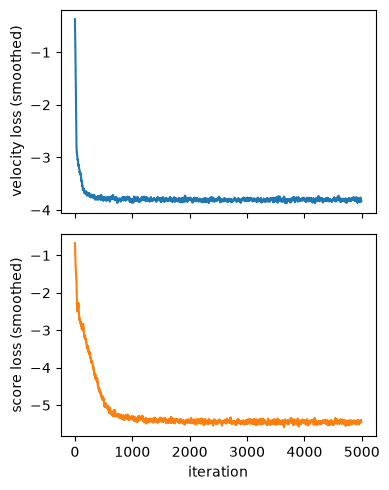

In [18]:
# Training curves (smoothed).
def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("score loss (smoothed)")
#ax[1].set_xscale("log")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the model's built-in samplers (inherited unchanged from
`EESI`):

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`.
- `model.sample_sde` integrates the reverse-time **SDE** using both `b` and `s`.

For a 1D XY chain there is no simple closed-form density to score against, so we
compare two physical observables of the generated vs. true target configurations:
the wrapped nearest-neighbour angle difference $\Delta\theta$ and the per-chain
energy $E=J\sum_i\cos\Delta\theta_i$.

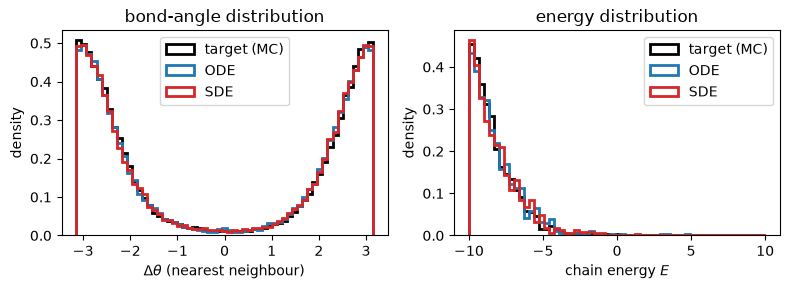

target (MC)   <E> = -12.2890   std(E) = 2.4850
ODE           <E> = -12.1394   std(E) = 2.5151
SDE           <E> = -12.1333   std(E) = 2.5867
Exact         <E> = -12.5599


In [21]:
N = 10
J=2
torch.manual_seed(1)
n_gen = 5000
x0 = sample_base(n_gen,N)
gen_ode = model.sample_ode(x0, n_steps=100)             # probability-flow ODE (drift only)
gen_sde = model.sample_sde(x0, n_steps=100, eps=0.5)    # reverse-time SDE (drift + score)



fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bins = np.linspace(-np.pi, np.pi, 60)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[0].hist(dtheta(x), bins=bins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[0].set_xlabel(r"$\Delta\theta$ (nearest neighbour)"); ax[0].set_ylabel("density")
ax[0].set_title("bond-angle distribution"); ax[0].legend()

ebins = np.linspace(-N + 1 - 1, N - 1 + 1, 60)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[1].hist(chain_energy(x,J), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].set_xlabel("chain energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend()
plt.tight_layout()
plt.show()

for x, lbl in [(x1_all, "target (MC)"), (gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x,J)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")

lbl="Exact"
dE = (N-1) * (-J*(iv(1,J)/iv(0,J)))
print(f"{lbl:12s}  <E> = {dE.mean():+.4f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways
(all inherited from `EESI`, and all just as valid on the geodesic interpolant):

- `entropy_estimate_dot`: mean of $-b\cdot s$ sampled on the interpolant (needs the score).
- `entropy_estimate_div`: mean of $\nabla\!\cdot b$ (score-free, Hutchinson divergence).
- `sample_ode_entropy_traj`: the running integral $-\int_0^t b\cdot s\,dt'$ along ODE paths.

entropy estimate (b·s)   : -4.7273 ± 0.0607
entropy estimate (div b) : -4.7109 ± 0.0678
entropy estimate (ODE path integral): -4.6701
exact entropy: -5.144001970005537


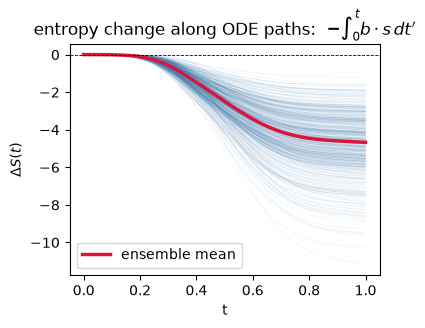

In [22]:
torch.manual_seed(2)
batch = 5000
means_dot, means_div = [], []
for _ in range(50):
    idx = torch.randint(0, n_data, (batch,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch,N)
    means_dot.append(model.entropy_estimate_dot(x1, x0).mean().item())
    means_div.append(model.entropy_estimate_div(x1, x0).mean().detach().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.4f} ± {np.std(means_dot):.4f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.4f} ± {np.std(means_div):.4f}")

# Running entropy change along many ODE paths.
x0 = sample_base(5000,N)
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.4f}")
dS = (N-1) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
print(f"exact entropy: {dS}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

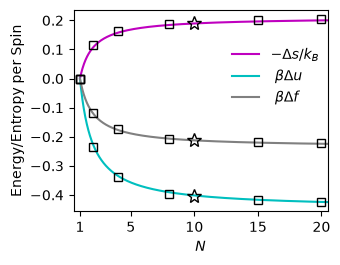

In [ ]:

Nspace = np.arange(1,21)
Nspace = np.linspace(1,21,1000)

ds = ((Nspace-1)/Nspace) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
de = ((Nspace-1)/Nspace) * (-J*(iv(1,J)/iv(0,J)))
df = de - ds
plt.figure(figsize=(3.5,2.75))
plt.plot(Nspace,-ds,'-m',mfc='none',label=r'$-\Delta s / k_B$',ms=5)
plt.plot(Nspace,de,'-c',mfc='none',label=r" $\beta \Delta u$",ms=5)
plt.plot(Nspace,df,'-',color='gray',mfc='none',label=r" $\beta \Delta f$",ms=5)

ds_eesi = -1.9214/10
de_eesi = -4.0488/10
df_eesi = de_eesi - ds_eesi

N_vals = [1,2,4,8,15,20]
N_vals = np.array(N_vals)
ds_vals = [0,-0.2328,-0.6554,-1.5100,-3.0045,-4.0836]
ds_vals = np.divide(ds_vals,N_vals)
de_vals = [0,-0.4720,-1.3521,-3.1748,-6.2736,-8.5082]
de_vals = np.divide(de_vals,N_vals)
df_vals = de_vals - ds_vals

plt.plot(10,de_eesi,'k*',mfc='none',ms=10)
plt.plot(10,-ds_eesi,'k*',mfc='none',ms=10)
plt.plot(10,df_eesi,'k*',mfc='none',ms=10)

plt.plot(N_vals,de_vals,'ks',mfc='none')
plt.plot(N_vals,-ds_vals,'ks',mfc='none')
plt.plot(N_vals,df_vals,'ks',mfc='none')

plt.xticks([1,5,10,15,20])
plt.xlim(0.5,20.5)
plt.legend(frameon=False,loc=(0.6,0.5))
plt.xlabel(r'$N$')
plt.ylabel('Energy/Entropy per Spin')
plt.tight_layout()
plt.show()

#### Save model

In [37]:
torch.save(model.net_b.state_dict(), 'xy_b.pth')
torch.save(model.net_s.state_dict(), 'xy_s.pth')

### Other Chain Lengths

In [51]:

N = 1            # 
J = 1.0          # 

model_N = xyEESI(
    model.net_b, model.net_s,
    d=N,
    path="trig2",
    gamma="sin2",
    gamma_scale=0.5,
).to(device)


# --- base p_0: independent uniform angles on the circle (trivial to sample) ---
def sample_base_N(B):
    return torch.rand(B, N, device=device) * (2 * np.pi) - np.pi

In [52]:
torch.manual_seed(1)
n_gen = 5000
x0 = sample_base_N(n_gen)
gen_ode = model_N.sample_ode(x0, n_steps=100)             # probability-flow ODE (drift only)
gen_sde = model_N.sample_sde(x0, n_steps=100, eps=0.3)    # reverse-time SDE (drift + score)


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x):                 # E = J * sum_i cos(dtheta_i)
    return (J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

for x, lbl in [(gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")

lbl="Exact"
dE = (N-1) * (-J*(iv(1,J)/iv(0,J)))
print(f"{lbl:12s}  <E> = {dE.mean():+.4f}")

ODE           <E> = +0.0000   std(E) = 0.0000
SDE           <E> = +0.0000   std(E) = 0.0000
Exact         <E> = +0.0000


entropy estimate (ODE path integral): +0.0000
exact entropy: -0.0


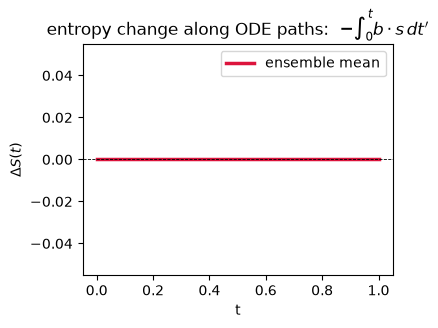

In [53]:

# Running entropy change along many ODE paths.
x0 = sample_base_N(5000)
traj, ent_traj, ts = model_N.sample_ode_entropy_traj(x0, n_steps=100)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.4f}")
dS = (N-1) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
print(f"exact entropy: {dS}")


fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

In [ ]:
torch.manual_seed(1)
n_gen = 5000
x0 = sample_base_N(n_gen)
gen_ode = model_N.sample_ode(x0, n_steps=100)             # probability-flow ODE (drift only)
gen_sde = model_N.sample_sde(x0, n_steps=100, eps=0.3)    # reverse-time SDE (drift + score)


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x):                 # E = J * sum_i cos(dtheta_i)
    return (J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

for x, lbl in [(gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")

lbl="Exact"
dE = (N-1) * (-J*(iv(1,J)/iv(0,J)))
print(f"{lbl:12s}  <E> = {dE.mean():+.4f}")